In [2]:
import numpy as np
from scipy.sparse import coo_matrix
from scipy.sparse.linalg import eigsh
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
from unsupervised_learning import swiss_roll

# **LOCALLY LINEAR EMBEDDING**

LLE maps its inputs into a **single global coordinate system** of **lower dimensionality**, and its optimizations does **not involve local minima**. By exploiting the **local symmetries of linear reconstructions**, LLE is able to learn the global structure of nonlinear manifolds, such as those generated by images of faces or documents of text.

### Assumptions
The assumption  behind LLE is that each datapoint can be reconstructed from a set of NearestNeighbors:
- true if data is not sparse
- true if the manyfold in the neighborhood of $\bm x$ is 'smooth' (allowing linear reconstruction)

## 1. THE ALGORITHM

LLE has 3 main phases:
1. Assign **neighbors** to each datapoint $\bm x$
2. Compute the **weights** $W_{ij}$ that best linearly reconstruct $\bm x$ from its neighbors
3. Compute the **low dimensional embedding** vectors $\bm y$

### 1.1 Neighbors Assignation
For each point $\bm x_i$ we assume tat its $k$ nearest neighbors lie close (or on) to a linear patch of the manifold.  
These patches reconstruct each datapoint $\bm x_i$ by means of linear coefficient $w_{ij}$;

### 1.2 Weights Computation
Weights $w_{ij}$ need to minimize the cost function 
$$\sum_i\left|\bm x_i-\sum_jw_{ij}\bm x_j\right|^2$$
Subject to the constraints:
- reconstruct $\bm x_i$ **only** from its $k$ nearest neighbors
- the rows of the weight matrix **sum to one** $\sum_j W_{ij}=1$


In [3]:
def compute_reconstruction_error(D: np.ndarray, W: np.ndarray, indices: np.ndarray):
    N = D.shape[0]
    err = 0
    for i in range(N):
        x_neighbors = D[indices[i]]
        x_recon = np.dot(W[i, indices[i]], x_neighbors)
        err += np.linalg.norm(D[i] - x_recon)**2
    return err


This is a **least square problem**. The solution has a closed form where we compute:
1. **Neighborhood correlation matrix:** $C_{jk}=\bm \eta_j \cdot \bm \eta_k$ and the matrix inverse $C^{-1}$
2. **Lagrange multipliers coefficients:** $\lambda=\alpha / \beta$ where 
   - $\alpha = 1-\sum_{jk} C^{-1}_{jk}(\bm x \cdot \bm \eta_k)$
   - $\beta = \sum_{jk}C^{-1}_{jk}$
3. **Weights:** $w_j=\sum_kC^{-1}_{jk}(\bm x \cdot \bm \eta_k + \lambda)$

If the correlation matrix is **nearly singular** it can be **conditioned** by adding a _small multiple of the identity matrix_ (penalty to large weights that exploit correlations).

In [4]:
def compute_weights(X: np.ndarray, ind: np.ndarray, reg=0.001) -> np.ndarray:
    N = X.shape[0]

    # Weights matrix
    W = np.zeros(shape=(N, N), dtype=np.float64)
    for x in range(N):
        x_neighbors = ind[x]

        # Correlation matrix of neighbors
        C = X[x_neighbors] @ X[x_neighbors].T

        # Conditioning
        C += np.eye(C.shape[0]) * reg
        CI = np.linalg.inv(C)

        # Computing Lagrange constraint
        xprod = X[x_neighbors] @ X[x]
        alpha = 1 - np.sum(CI * (xprod))
        beta = CI.sum()
        l = alpha/beta

        # Solving the least square problem
        W[x, x_neighbors] = np.sum(CI * (xprod+l), axis=1)
    return W

Weights are invariant to: 
- **rotations**
- **rescalings**
- **translations** (_sum to one_ constraint)

Weights should be able to reconstruct each datapoint in $d$ dimensions as well as in $D$.

### 1.3 Compute the Embedding

Coordinates $\bm y_i$ need to optimize the **embedding cost function:** 
$$\Phi(\bm y)=\sum_i \left| \bm y_i-\sum_j w_{ij} \bm y_j \right|^2$$

This is a **sparse eigenvalue-eigenvector problem**. The steps are:
1. **Translate** (center) the **embedding vectors** so that $\sum_i\bm y_i=0$
2. **Impose unit covariance** to vectors $\frac{1}{N}\sum_i\bm y_i^T \cdot \bm y_i=\mathbb I$ identity matrix

This is a quadratic form 
$$\displaystyle \Phi(\bm y)=\sum_{ij}M_{ij}(\bm y_i \cdot \bm y_j)$$
where $M\in\mathbb R^{N\times N}$ is the symmetric matrix: 
$$\displaystyle M_{ij}=\delta_{ij}-w_{ij}-w_{ji}+\sum_k w_{ki}w_{kj}$$

- The bottom $d+1$ eigenvectors of $M$ contain the optimal embedding.  
- The bottom eigenvector is discarded as it is the unit vector and represents a free translation mode.  
- $M$ can be stored and manipulated as a sparse matrix.

In [5]:
def compute_embedding(W: np.ndarray, n_components):

    # Compute matrix M
    M = np.eye(W.shape[0]) - W - W.T + W.T @ W
    M = coo_matrix(M)

    # Solve the sparse eigenvalue-eigenvectors problem
    _, eig = eigsh(M, n_components+1, sigma=0, which='LM')
    return eig[:, 1:n_components+1]

**Summarizing:**

In [6]:
def _locally_linear_embedding(X, n_neighbors, n_components, reg):
    # Find neighbors of each datapoint
    nbrs = NearestNeighbors(n_neighbors=n_neighbors+1).fit(X)
    ind = nbrs.kneighbors(X, return_distance=False)[:, 1:]

    # Compute weights
    W = compute_weights(X, ind, reg)

    # Compute the embedding vectors
    embedding = compute_embedding(W, n_components)

    # Compute the reconstruction error
    reconstruction_error = compute_reconstruction_error(X, W, ind)
    return embedding, reconstruction_error


class LLE:

    def __init__(self, n_neighbors=5, n_components=2, reg=0.001,):
        self.n_neighbors = n_neighbors
        self.n_components = n_components
        self.reg = reg

    def _fit_transform(self, X):
        self.embedding_, self.reconstruction_error_ = _locally_linear_embedding(
            X=X, n_neighbors=self.n_neighbors, n_components=self.n_components, reg=self.reg)

    def fit(self, X: np.ndarray):
        self._fit_transform(X)
        return self

    def fit_transform(self, X):
        self._fit_transform(X)
        return self.embedding_

## 2. PARAMETERS AND LIMITATIONS

### 2.1 Parameters

The technique has one single parameter: $k$ the number of neighbors.
The conditioning factor `reg` can also be considered a parameter of the technique but is usually a standard value or computed at runtime.

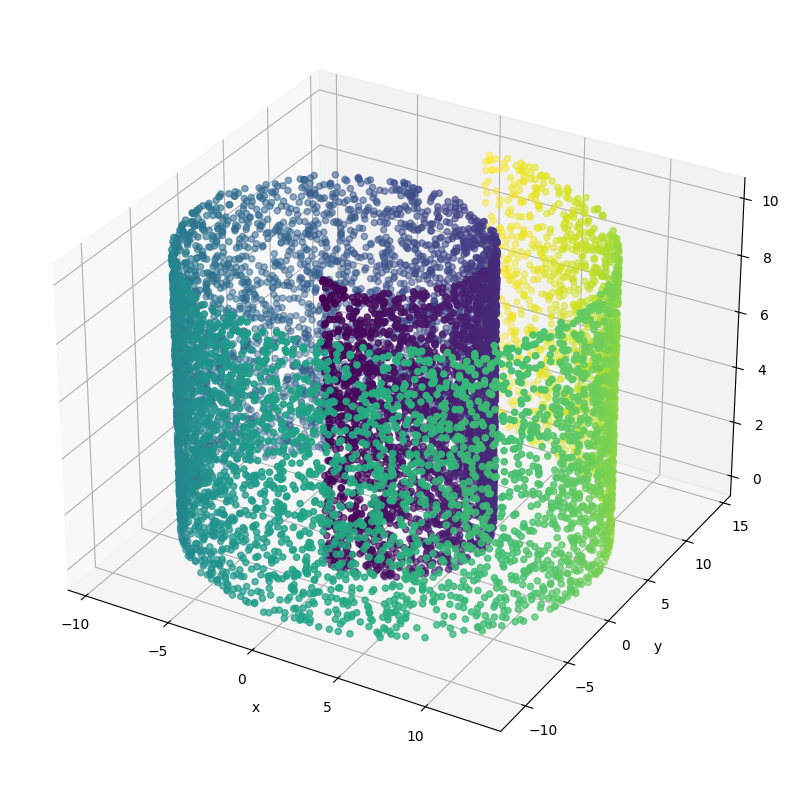

In [7]:
X = swiss_roll(10000)
clr = X[:, 0]**2 + X[:, 1]**2

plt.figure(figsize=(12, 10))
ax = plt.axes(projection='3d')
ax.scatter3D(X[:, 0], X[:, 1], X[:, 2], c=clr)
plt.xlabel('x')
plt.ylabel('y')
ax.set_zlabel('z')

plt.show()

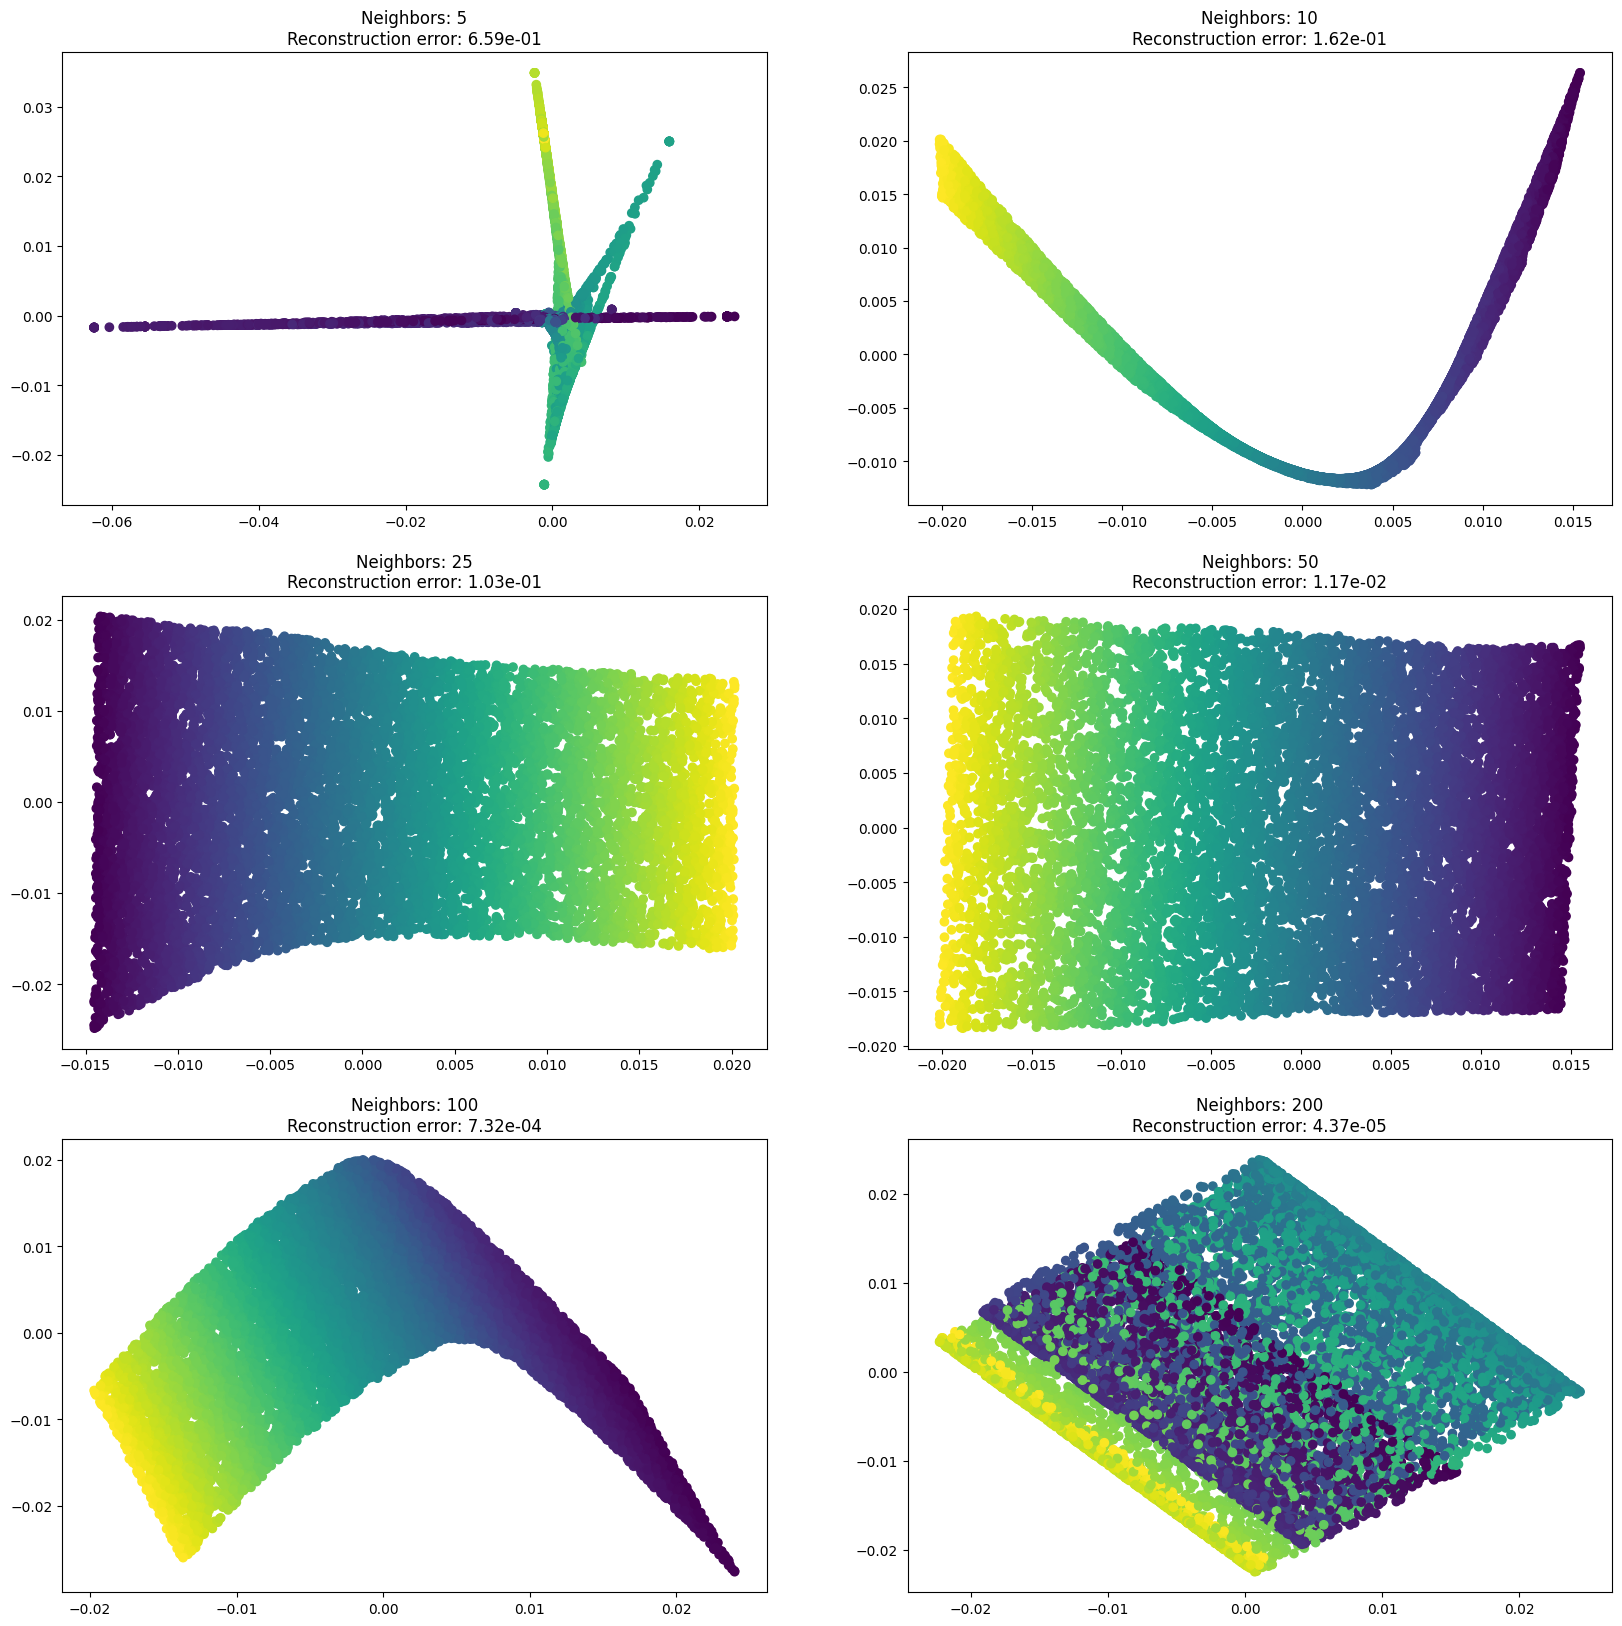

In [ ]:
fig, ax = plt.subplots(2, 3, figsize=(20, 20))
ax = ax.ravel()
for idx, neigh in enumerate([5, 10, 25, 50, 100, 200]):
    lle = LLE(n_neighbors=neigh)
    Y = lle.fit_transform(X)
    ax[idx].scatter(Y[:, 0], Y[:, 1], c=clr)
    ax[idx].set_title(
        f"Neighbors: {neigh}\nReconstruction error: {lle.reconstruction_error_:.2e}")

plt.show()

### 2.3 Limitations

Due to the assumptions:
- susceptible to noise
- requires the assumptions to be true
- cannot reconstruct the global structure in a manner that respects the original shape (like Isomap).

Some extensions of the original method allow to preserve the original shape.  
If we take $k$-NearestNeighbors, then the embedding dimension $d$ must be such that $d<k$.

## 3. COMPARISON WITH OTHER TECHNIQUES

- MDS: pairwise distances along straight lines
- Isomap: geodesic distances between farway points
- Autoencoders and neural networks: Iterative hill-climbing methods do not have the same guarantees of global optimality or convergence and often involve many more free parameters.

LLE is not limited in practice to manifolds of extremely low dimensionality or codimensionality.  
No need to recompute the embedding each time for increasing values of $d$.